c:\Users\BUI QUANG HUNG\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
01:40:58 - cmdstanpy - INFO - Chain [1] start processing
01:41:13 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\BUI QUANG HUNG\AppData\Local\Temp\ipykernel_29360\2458135838.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_season = eval_df.groupby('season_name').apply(lambda x: np.sqrt(mean_squared_error(x['y'], x['pred'])))
C:\Users\BUI QUANG H

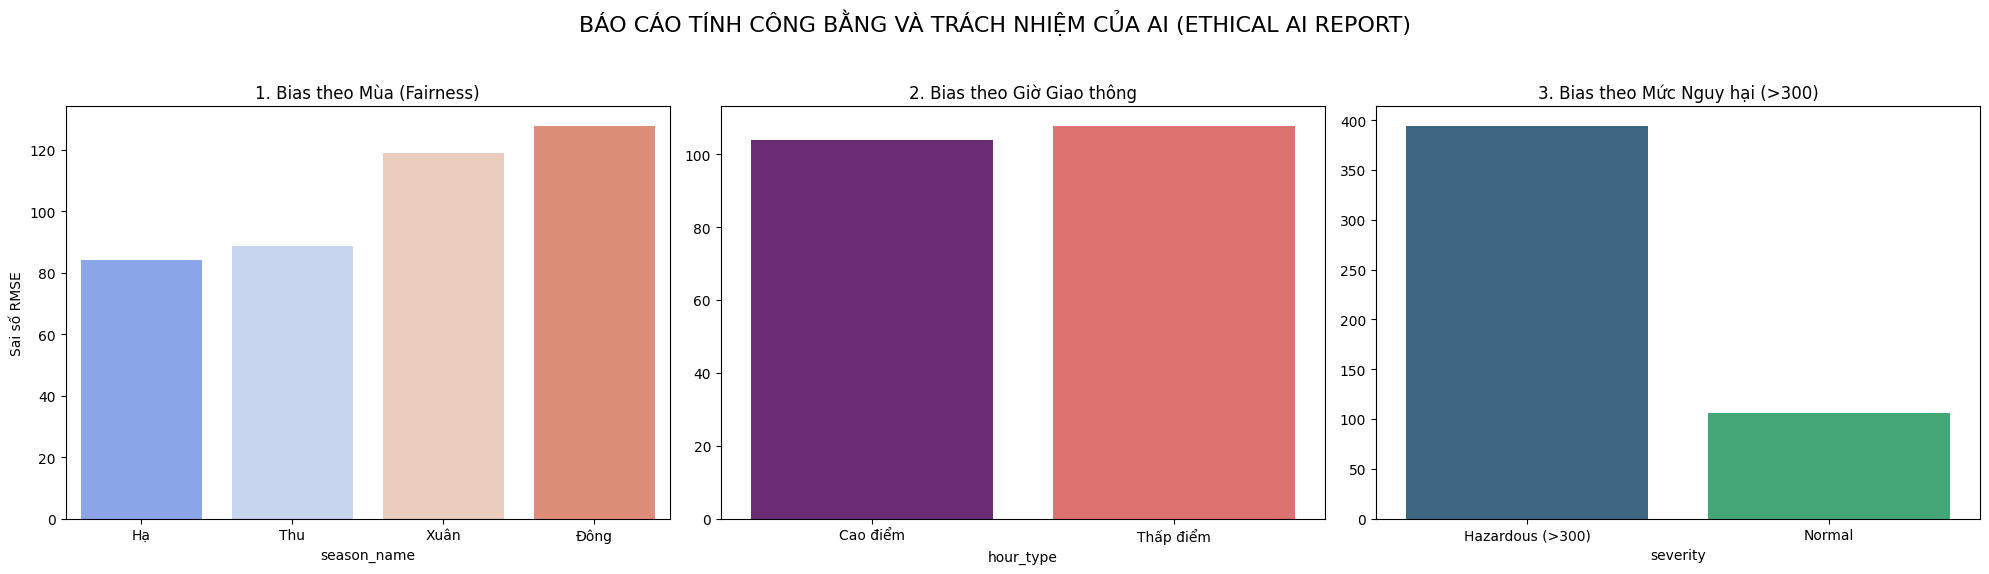


🔍 PHÂN TÍCH ĐẠO ĐỨC DỮ LIỆU:
- Lỗi cao nhất ở: Mùa ĐÔNG và Nhóm HAZARDOUS (>300)
- Hệ quả đạo đức: Nếu mô hình dự báo sai ở mức Nguy hại, người dân sẽ không kịp phòng tránh.
- Giải pháp: Cần thu thập thêm dữ liệu Hazardous và tăng trọng số học cho mùa Đông.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# 1. Đọc dữ liệu
df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
df['ds'] = pd.to_datetime(df['local_time'])
df['y'] = df['aqi']

# 2. Chia dữ liệu: Test 1 năm (8760 giờ) để đủ 4 mùa đánh giá Bias
test_size = 8760 
train, test = df.iloc[:-test_size], df.iloc[-test_size:]

# 3. Huấn luyện và Dự báo diện rộng
model = Prophet(daily_seasonality=True, yearly_seasonality=True).fit(train)
forecast = model.predict(test[['ds']])

# 4. Chuẩn bị dữ liệu đánh giá Bias
eval_df = test.copy()
eval_df['pred'] = forecast['yhat'].values
eval_df['season_name'] = eval_df['season'].map({0:'Đông', 1:'Xuân', 2:'Hạ', 3:'Thu'})
eval_df['hour_type'] = eval_df['is_rush_hour'].map({1:'Cao điểm', 0:'Thấp điểm'})
eval_df['severity'] = eval_df['y'].apply(lambda x: 'Hazardous (>300)' if x > 300 else 'Normal')

# Tính RMSE cho từng tiêu chí Bias
rmse_season = eval_df.groupby('season_name').apply(lambda x: np.sqrt(mean_squared_error(x['y'], x['pred'])))
rmse_hour = eval_df.groupby('hour_type').apply(lambda x: np.sqrt(mean_squared_error(x['y'], x['pred'])))
rmse_severity = eval_df.groupby('severity').apply(lambda x: np.sqrt(mean_squared_error(x['y'], x['pred'])))

# 5. TRỰC QUAN HÓA BÁO CÁO ĐẠO ĐỨC (3 Biểu đồ)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Bias 1: Theo Mùa
sns.barplot(x=rmse_season.index, y=rmse_season.values, ax=ax1, palette='coolwarm')
ax1.set_title('1. Bias theo Mùa (Fairness)')
ax1.set_ylabel('Sai số RMSE')

# Bias 2: Theo Khung giờ
sns.barplot(x=rmse_hour.index, y=rmse_hour.values, ax=ax2, palette='magma')
ax2.set_title('2. Bias theo Giờ Giao thông')

# Bias 3: Theo Mức Nguy hại (Quan trọng nhất về Đạo đức)
sns.barplot(x=rmse_severity.index, y=rmse_severity.values, ax=ax3, palette='viridis')
ax3.set_title('3. Bias theo Mức Nguy hại (>300)')

plt.suptitle('BÁO CÁO TÍNH CÔNG BẰNG VÀ TRÁCH NHIỆM CỦA AI (ETHICAL AI REPORT)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

# 6. KẾT LUẬN CHO BÁO CÁO
print("\n" + "="*60)
print("🔍 PHÂN TÍCH ĐẠO ĐỨC DỮ LIỆU:")
print(f"- Lỗi cao nhất ở: Mùa {rmse_season.idxmax().upper()} và Nhóm {rmse_severity.idxmax().upper()}")
print("- Hệ quả đạo đức: Nếu mô hình dự báo sai ở mức Nguy hại, người dân sẽ không kịp phòng tránh.")
print("- Giải pháp: Cần thu thập thêm dữ liệu Hazardous và tăng trọng số học cho mùa Đông.")
print("="*60)